# 🫀 Predição de Doenças Cardíacas — BRFSS 2015
> **Dataset:** Heart Disease Health Indicators (CDC/Kaggle)  
> **Objetivo:** EDA completa + pré-processamento para uso em modelo de ML  
> **Features:** autorrelatadas (sem exames laboratoriais obrigatórios)

---
## Índice
1. [Instalação e Imports](#1)
2. [Carregamento e Visão Geral](#2)
3. [Análise Exploratória (EDA)](#3)
4. [Pré-processamento](#4)
5. [Balanceamento de Classes](#5)
6. [Exportação dos Datasets](#6)


## 1. Instalação e Imports <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

C_POS  = '#D85A30'
C_NEG  = '#1D9E75'
C_BLUE = '#378ADD'
C_GRAY = '#B4B2A9'
C_BG   = '#F8F8F6'

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({
    'figure.facecolor': C_BG,
    'axes.facecolor': C_BG,
    'axes.spines.top': False,
    'axes.spines.right': False
})

## 2. Carregamento e Visão Geral <a id='2'></a>

In [2]:
DATA_PATH = 'heart_disease_health_indicators_BRFSS2015.csv'

df = pd.read_csv(DATA_PATH)
df.shape
df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
COL_LABEL = {
    'HeartDiseaseorAttack': 'Doença Cardíaca (target)',
    'HighBP':        'Pressão Alta (diagnóstico médico)',
    'HighChol':      'Colesterol Alto (diagnóstico médico)',
    'CholCheck':     'Check colesterol nos últimos 5 anos',
    'BMI':           'Índice de Massa Corporal',
    'Smoker':        'Fumante (>100 cigarros na vida)',
    'Stroke':        'AVC prévio',
    'Diabetes':      'Diabetes (0=Não, 1=Pré-diabetes, 2=Sim)',
    'PhysActivity':  'Atividade Física (últimos 30 dias)',
    'Fruits':        'Consome Frutas diariamente',
    'Veggies':       'Consome Vegetais diariamente',
    'HvyAlcoholConsump': 'Consumo pesado de álcool',
    'AnyHealthcare': 'Tem plano de saúde',
    'NoDocbcCost':   'Deixou de ir ao médico por custo',
    'GenHlth':       'Saúde Geral auto-avaliada (1=Excelente → 5=Ruim)',
    'MentHlth':      'Dias com saúde mental ruim (0-30)',
    'PhysHlth':      'Dias com saúde física ruim (0-30)',
    'DiffWalk':      'Dificuldade para caminhar ou subir escadas',
    'Sex':           'Sexo (0=Feminino, 1=Masculino)',
    'Age':           'Faixa etária (1=18-24 até 13=80+)',
    'Education':     'Escolaridade (1=Nunca estudou → 6=Superior)',
    'Income':        'Faixa de renda (1=<10k → 8=>75k USD/ano)',
}

for col, label in COL_LABEL.items():
    print(f'  {col:<25} → {label}')

  HeartDiseaseorAttack      → Doença Cardíaca (target)
  HighBP                    → Pressão Alta (diagnóstico médico)
  HighChol                  → Colesterol Alto (diagnóstico médico)
  CholCheck                 → Check colesterol nos últimos 5 anos
  BMI                       → Índice de Massa Corporal
  Smoker                    → Fumante (>100 cigarros na vida)
  Stroke                    → AVC prévio
  Diabetes                  → Diabetes (0=Não, 1=Pré-diabetes, 2=Sim)
  PhysActivity              → Atividade Física (últimos 30 dias)
  Fruits                    → Consome Frutas diariamente
  Veggies                   → Consome Vegetais diariamente
  HvyAlcoholConsump         → Consumo pesado de álcool
  AnyHealthcare             → Tem plano de saúde
  NoDocbcCost               → Deixou de ir ao médico por custo
  GenHlth                   → Saúde Geral auto-avaliada (1=Excelente → 5=Ruim)
  MentHlth                  → Dias com saúde mental ruim (0-30)
  PhysHlth                  →

In [4]:
print('=== TIPOS E NULOS ===')
print(df.info())
print('\n=== ESTATÍSTICAS DESCRITIVAS ===')
df.describe().round(2)

=== TIPOS E NULOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 n

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.0,253680.00,253680.00,...,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00
mean,0.09,0.43,0.42,0.96,28.38,0.44,0.04,0.3,0.76,0.63,...,0.95,0.08,2.51,3.18,4.24,0.17,0.44,8.03,5.05,6.05
std,0.29,0.49,0.49,0.19,6.61,0.50,0.20,0.7,0.43,0.48,...,0.22,0.28,1.07,7.41,8.72,0.37,0.50,3.05,0.99,2.07
min,0.00,0.00,0.00,0.00,12.00,0.00,0.00,0.0,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,1.00,24.00,0.00,0.00,0.0,1.00,0.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00
50%,0.00,0.00,0.00,1.00,27.00,0.00,0.00,0.0,1.00,1.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00
75%,0.00,1.00,1.00,1.00,31.00,1.00,0.00,0.0,1.00,1.00,...,1.00,0.00,3.00,2.00,3.00,0.00,1.00,10.00,6.00,8.00
max,1.00,1.00,1.00,1.00,98.00,1.00,1.00,2.0,1.00,1.00,...,1.00,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00


In [5]:
for col in df.columns:
    uniq = sorted(df[col].unique())
    print(f'{col:<25}: {uniq}')

HeartDiseaseorAttack     : [np.float64(0.0), np.float64(1.0)]
HighBP                   : [np.float64(0.0), np.float64(1.0)]
HighChol                 : [np.float64(0.0), np.float64(1.0)]
CholCheck                : [np.float64(0.0), np.float64(1.0)]
BMI                      : [np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(33.0), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(40.0), np.float64(41.0), np.float64(42.0), np.float64(43.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(49.0), np.float64(50.0), np.float64(51.0), np.f

## 3. Análise Exploratória (EDA) <a id='3'></a>

### 3.1 Balanceamento de Classes
> ⚠️ **Problema crítico:** o dataset é fortemente desbalanceado (~9% positivos).  

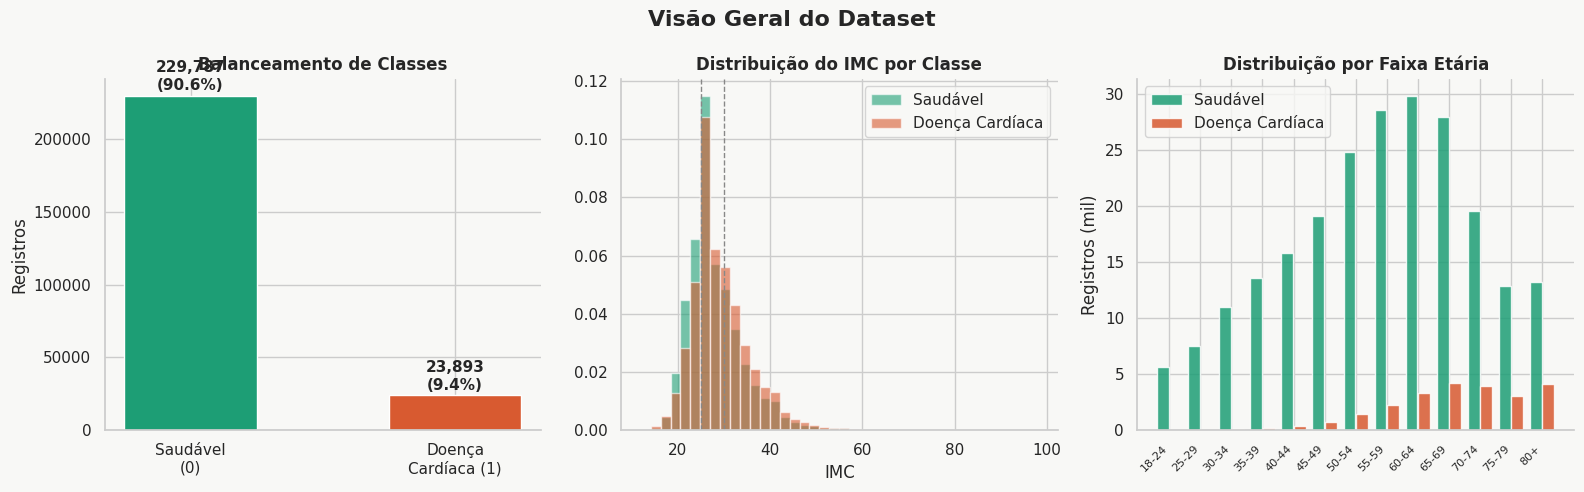

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Visão Geral do Dataset', fontsize=16, fontweight='bold')

# Balanceamento
ax = axes[0]
counts = df['HeartDiseaseorAttack'].value_counts()
bars = ax.bar(['Saudável\n(0)', 'Doença\nCardíaca (1)'],
              [counts[0], counts[1]], color=[C_NEG, C_POS], width=0.5, edgecolor='white')
for bar, v in zip(bars, [counts[0], counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Balanceamento de Classes', fontweight='bold')
ax.set_ylabel('Registros')

# Distribuição IMC
ax = axes[1]
for val, cor, lbl in [(0, C_NEG, 'Saudável'), (1, C_POS, 'Doença Cardíaca')]:
    ax.hist(df[df['HeartDiseaseorAttack']==val]['BMI'], bins=40, alpha=0.6,
            color=cor, label=lbl, density=True)
ax.axvline(25, color='#888', ls='--', lw=1)
ax.axvline(30, color='#888', ls='--', lw=1)
ax.set_title('Distribuição do IMC por Classe', fontweight='bold')
ax.set_xlabel('IMC'); ax.legend()

# Faixa etária
ax = axes[2]
age_labels = ['18-24','25-29','30-34','35-39','40-44','45-49',
               '50-54','55-59','60-64','65-69','70-74','75-79','80+']
an = df[df['HeartDiseaseorAttack']==0]['Age'].value_counts().sort_index()
ap = df[df['HeartDiseaseorAttack']==1]['Age'].value_counts().sort_index()
x = np.arange(len(age_labels))
ax.bar(x-0.2, an.values/1000, 0.38, color=C_NEG, label='Saudável', alpha=0.85)
ax.bar(x+0.2, ap.values/1000, 0.38, color=C_POS, label='Doença Cardíaca', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(age_labels, rotation=45, ha='right', fontsize=8)
ax.set_title('Distribuição por Faixa Etária', fontweight='bold')
ax.set_ylabel('Registros (mil)'); ax.legend()

plt.tight_layout()
plt.show()

### 3.2 Features Binárias vs Doença Cardíaca

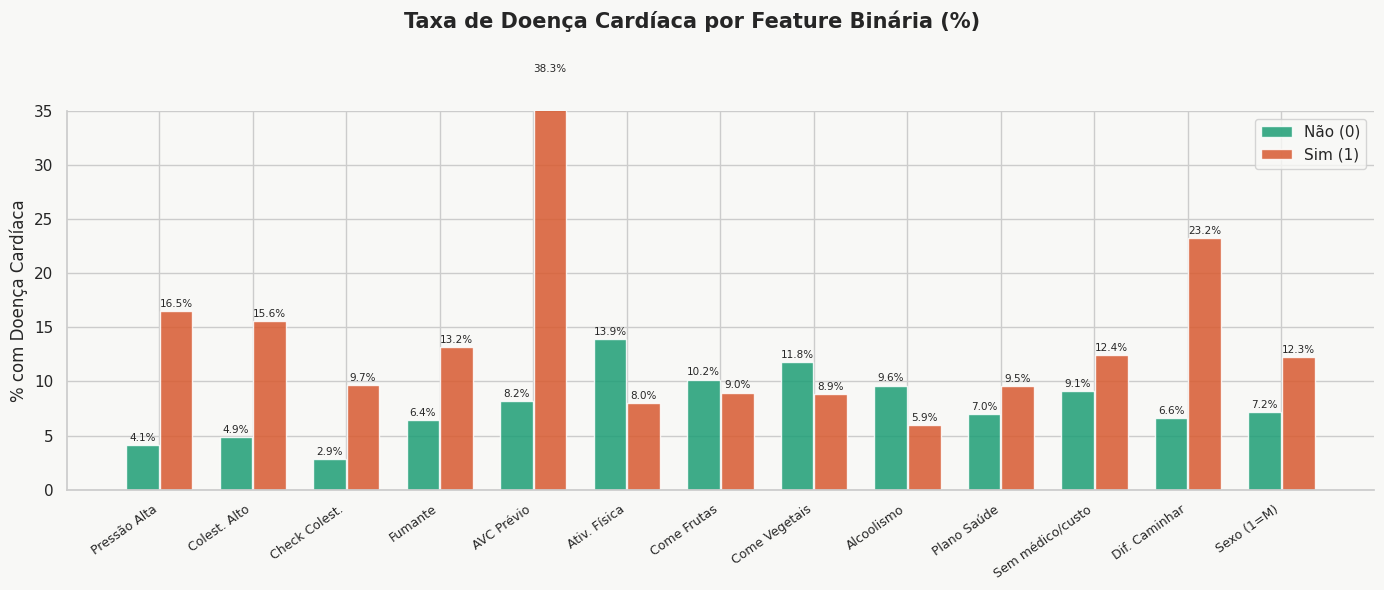

In [7]:
binary_cols = ['HighBP','HighChol','CholCheck','Smoker','Stroke','PhysActivity',
               'Fruits','Veggies','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex']

labels_pt = {
    'HighBP':'Pressão Alta','HighChol':'Colest. Alto','CholCheck':'Check Colest.',
    'Smoker':'Fumante','Stroke':'AVC Prévio','PhysActivity':'Ativ. Física',
    'Fruits':'Come Frutas','Veggies':'Come Vegetais','HvyAlcoholConsump':'Alcoolismo',
    'AnyHealthcare':'Plano Saúde','NoDocbcCost':'Sem médico/custo',
    'DiffWalk':'Dif. Caminhar','Sex':'Sexo (1=M)',
}

rates = {col: (df[df[col]==0]['HeartDiseaseorAttack'].mean()*100,
               df[df[col]==1]['HeartDiseaseorAttack'].mean()*100)
         for col in binary_cols}

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Taxa de Doença Cardíaca por Feature Binária (%)', fontsize=15, fontweight='bold')

x = np.arange(len(binary_cols))
r0s = [rates[c][0] for c in binary_cols]
r1s = [rates[c][1] for c in binary_cols]
b0 = ax.bar(x-0.18, r0s, 0.35, label='Não (0)', color=C_NEG, alpha=0.85)
b1 = ax.bar(x+0.18, r1s, 0.35, label='Sim (1)', color=C_POS, alpha=0.85)
for bar in list(b0)+list(b1):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.2, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x)
ax.set_xticklabels([labels_pt[c] for c in binary_cols], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('% com Doença Cardíaca')
ax.set_ylim(0, 35)
ax.legend()
plt.tight_layout()
plt.show()

### 3.3 Features Ordinais vs Doença Cardíaca

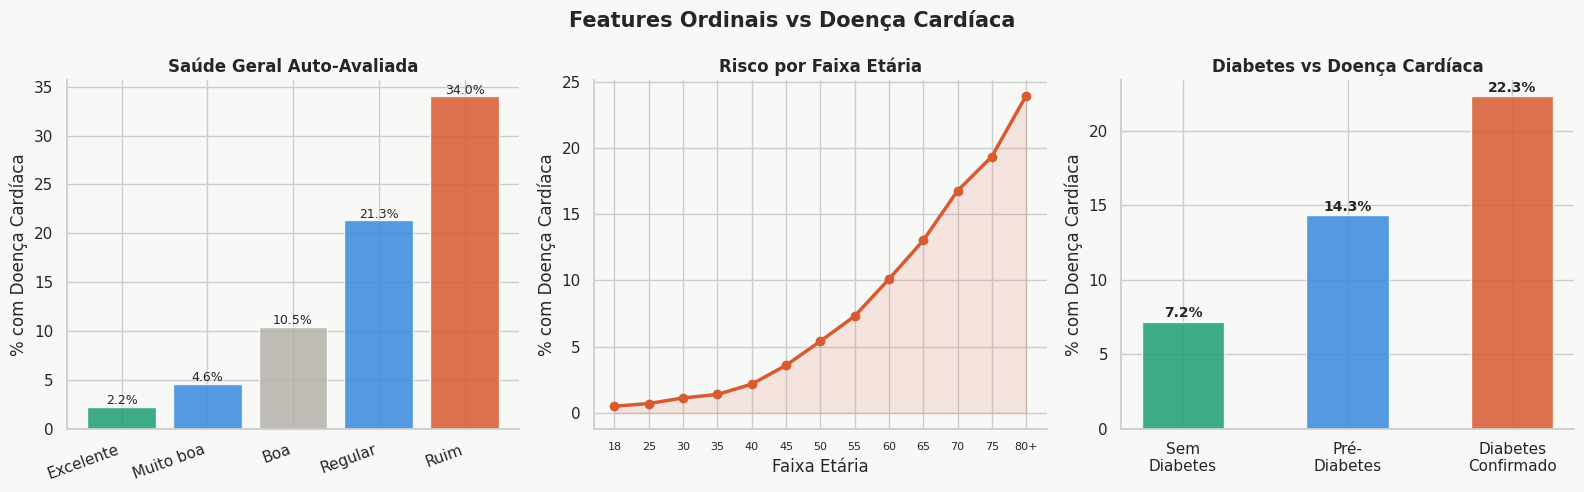

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Features Ordinais vs Doença Cardíaca', fontsize=15, fontweight='bold')

# GenHlth
ax = axes[0]
gh = df.groupby('GenHlth')['HeartDiseaseorAttack'].mean()*100
ax.bar(gh.index, gh.values, color=[C_NEG, C_BLUE, C_GRAY, C_BLUE, C_POS], alpha=0.85)
ax.set_xticks([1,2,3,4,5])
ax.set_xticklabels(['Excelente','Muito boa','Boa','Regular','Ruim'], rotation=20, ha='right')
ax.set_title('Saúde Geral Auto-Avaliada', fontweight='bold')
ax.set_ylabel('% com Doença Cardíaca')
for i, v in zip(gh.index, gh.values):
    ax.text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)

# Age
ax = axes[1]
ag = df.groupby('Age')['HeartDiseaseorAttack'].mean()*100
ax.plot(ag.index, ag.values, marker='o', color=C_POS, linewidth=2.5)
ax.fill_between(ag.index, ag.values, alpha=0.12, color=C_POS)
ax.set_xticks(range(1,14))
ax.set_xticklabels(['18','25','30','35','40','45','50','55','60','65','70','75','80+'], fontsize=8)
ax.set_xlabel('Faixa Etária')
ax.set_title('Risco por Faixa Etária', fontweight='bold')
ax.set_ylabel('% com Doença Cardíaca')

# Diabetes
ax = axes[2]
db = df.groupby('Diabetes')['HeartDiseaseorAttack'].mean()*100
ax.bar([0,1,2], db.values, color=[C_NEG, C_BLUE, C_POS], alpha=0.85, width=0.5)
ax.set_xticks([0,1,2])
ax.set_xticklabels(['Sem\nDiabetes','Pré-\nDiabetes','Diabetes\nConfirmado'])
ax.set_title('Diabetes vs Doença Cardíaca', fontweight='bold')
ax.set_ylabel('% com Doença Cardíaca')
for i, v in enumerate(db.values):
    ax.text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.4 Correlação e Importância de Features

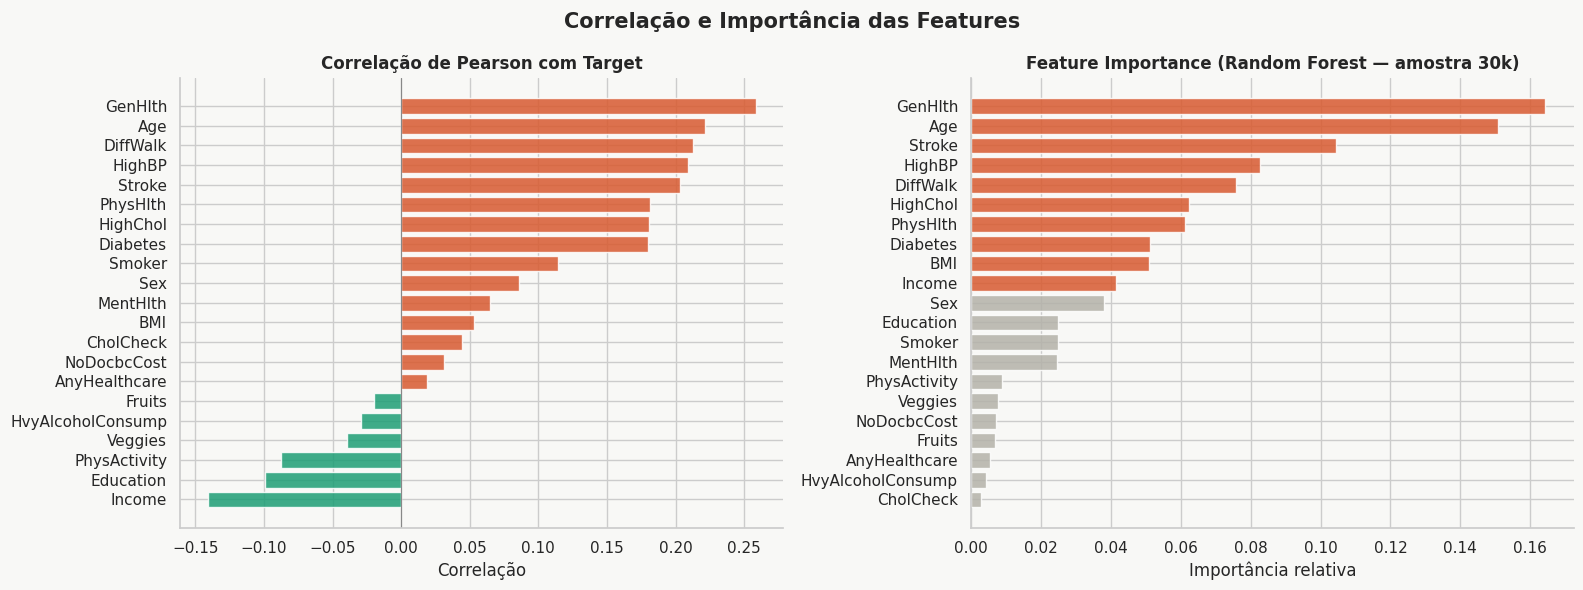

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlação e Importância das Features', fontsize=15, fontweight='bold')

# Correlação com target
ax = axes[0]
corr = df.corr()[['HeartDiseaseorAttack']].drop('HeartDiseaseorAttack')
corr = corr.sort_values('HeartDiseaseorAttack', ascending=False)
colors = [C_POS if v > 0 else C_NEG for v in corr['HeartDiseaseorAttack']]
ax.barh(corr.index[::-1], corr['HeartDiseaseorAttack'].values[::-1],
        color=colors[::-1], alpha=0.85)
ax.axvline(0, color='#888', linewidth=0.8)
ax.set_title('Correlação de Pearson com Target', fontweight='bold')
ax.set_xlabel('Correlação')

# Feature importance (RF em amostra)
ax = axes[1]
sample = df.sample(30000, random_state=42)
X_s = sample.drop('HeartDiseaseorAttack', axis=1)
y_s = sample['HeartDiseaseorAttack']
rf = RandomForestClassifier(n_estimators=80, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_s, y_s)
imp = pd.Series(rf.feature_importances_, index=X_s.columns).sort_values(ascending=True)
imp_colors = [C_POS if v > imp.median() else C_GRAY for v in imp.values]
ax.barh(imp.index, imp.values, color=imp_colors, alpha=0.85)
ax.set_title('Feature Importance (Random Forest — amostra 30k)', fontweight='bold')
ax.set_xlabel('Importância relativa')

plt.tight_layout()
plt.show()

## 4. Pré-processamento <a id='4'></a>

| Etapa | Descrição |
|---|---|
| **Tipos** | Conversão para `int8` (reduz memória ~8×) |
| **BMI outliers** | Cap no percentil 99.5% |
| **`BMI_cat`** | Categorização: 0=Abaixo peso, 1=Normal, 2=Sobrepeso, 3=Obeso |
| **`HealthyLifestyle`** | Score 0-5 somando hábitos saudáveis |


In [10]:
df_proc = df.copy()

# 1. Converter tipos para economizar memória
int8_cols = ['HeartDiseaseorAttack','HighBP','HighChol','CholCheck','Smoker',
             'Stroke','Diabetes','PhysActivity','Fruits','Veggies','HvyAlcoholConsump',
             'AnyHealthcare','NoDocbcCost','DiffWalk','Sex','GenHlth','Age','Education','Income']
df_proc[int8_cols] = df_proc[int8_cols].astype('int8')

# 2. BMI: cap outliers extremos
bmi_cap = df_proc['BMI'].quantile(0.995)
df_proc['BMI'] = df_proc['BMI'].clip(upper=bmi_cap)
print(f'BMI cap aplicado em: {bmi_cap}')

# 3. Feature: categorização do IMC
df_proc['BMI_cat'] = pd.cut(
    df_proc['BMI'],
    bins=[0, 18.5, 25, 30, 200],
    labels=[0, 1, 2, 3]
).astype('int8')
print('BMI_cat criado (0=Abaixo peso, 1=Normal, 2=Sobrepeso, 3=Obeso)')
print(df_proc['BMI_cat'].value_counts().sort_index())

BMI cap aplicado em: 55.0
BMI_cat criado (0=Abaixo peso, 1=Normal, 2=Sobrepeso, 3=Obeso)
BMI_cat
0     3127
1    86099
2    91176
3    73278
Name: count, dtype: int64


Correlação das novas features com target:
                  HeartDiseaseorAttack
HealthyLifestyle             -0.103276
BMI_cat                       0.058063


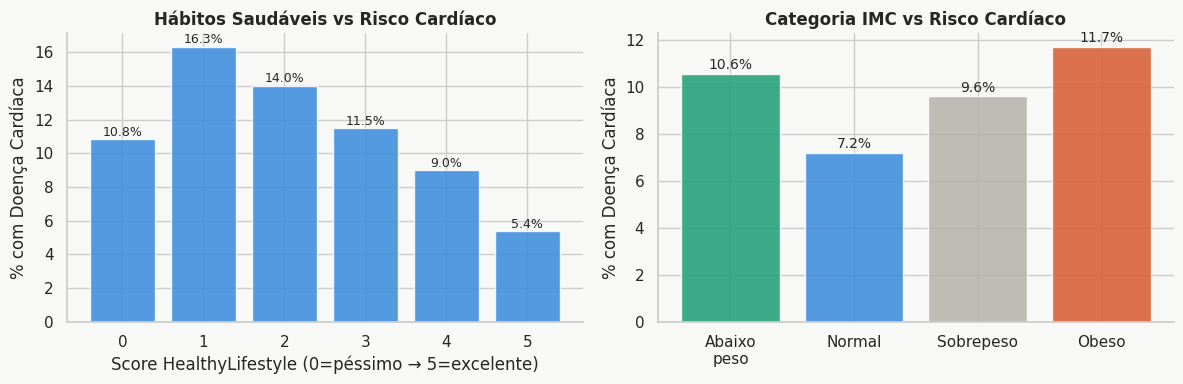

In [11]:
# 4. Feature: score de hábitos saudáveis (0-5)
df_proc['HealthyLifestyle'] = (
    (df_proc['PhysActivity'] == 1).astype(int) +
    (df_proc['Fruits']       == 1).astype(int) +
    (df_proc['Veggies']      == 1).astype(int) +
    (df_proc['HvyAlcoholConsump'] == 0).astype(int) +
    (df_proc['Smoker']       == 0).astype(int)
).astype('int8')

# Verificar correlação da nova feature com o target
corr_new = df_proc[['HealthyLifestyle','BMI_cat','HeartDiseaseorAttack']].corr()
print('Correlação das novas features com target:')
print(corr_new[['HeartDiseaseorAttack']].drop('HeartDiseaseorAttack'))

# Visualizar relação HealthyLifestyle vs risco
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hl_rate = df_proc.groupby('HealthyLifestyle')['HeartDiseaseorAttack'].mean()*100
axes[0].bar(hl_rate.index, hl_rate.values, color=C_BLUE, alpha=0.85)
axes[0].set_xlabel('Score HealthyLifestyle (0=péssimo → 5=excelente)')
axes[0].set_ylabel('% com Doença Cardíaca')
axes[0].set_title('Hábitos Saudáveis vs Risco Cardíaco', fontweight='bold')
for i, v in zip(hl_rate.index, hl_rate.values):
    axes[0].text(i, v+0.2, f'{v:.1f}%', ha='center', fontsize=9)

bmi_rate = df_proc.groupby('BMI_cat')['HeartDiseaseorAttack'].mean()*100
axes[1].bar([0,1,2,3], bmi_rate.values, color=[C_NEG,C_BLUE,C_GRAY,C_POS], alpha=0.85)
axes[1].set_xticks([0,1,2,3])
axes[1].set_xticklabels(['Abaixo\npeso','Normal','Sobrepeso','Obeso'])
axes[1].set_ylabel('% com Doença Cardíaca')
axes[1].set_title('Categoria IMC vs Risco Cardíaco', fontweight='bold')
for i, v in enumerate(bmi_rate.values):
    axes[1].text(i, v+0.2, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 5. Balanceamento de Classes <a id='5'></a>

Estratégia: **undersampling** da classe majoritária com ratio **1:3** (positivos:negativos).  
Isso preserva toda a informação dos casos positivos e reduz o viés, sem criar dados sintéticos.

> Para produção, vale testar também **SMOTE** (oversampling sintético) e **class_weight='balanced'** nos modelos.


Dataset COMPLETO (para avaliação/produção):
  Total: 253,680 | Positivos: 23,893 (9.4%)

Dataset BALANCEADO (para treino):
  Total: 95,572 | Positivos: 23,893 (25.0%)


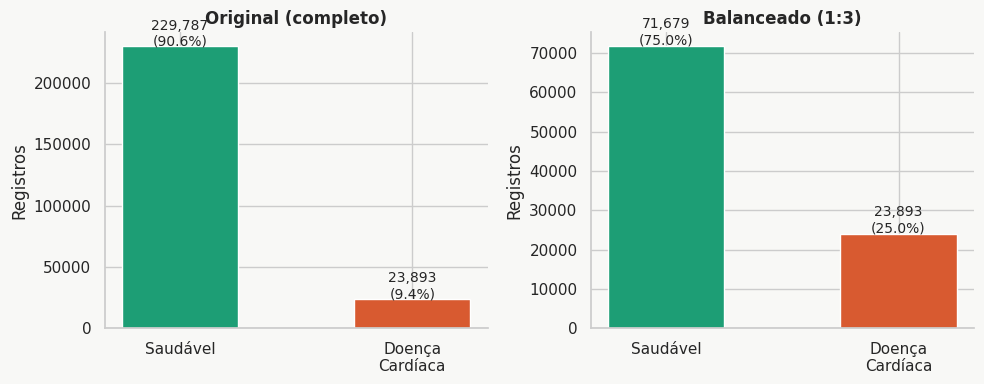

In [12]:
pos = df_proc[df_proc['HeartDiseaseorAttack'] == 1]
neg = df_proc[df_proc['HeartDiseaseorAttack'] == 0]

# Undersampling: ratio 1:3
neg_under = neg.sample(n=len(pos) * 3, random_state=42)
df_balanced = pd.concat([pos, neg_under]).sample(frac=1, random_state=42).reset_index(drop=True)

print('Dataset COMPLETO (para avaliação/produção):')
print(f'  Total: {df_proc.shape[0]:,} | Positivos: {df_proc["HeartDiseaseorAttack"].sum():,} ({df_proc["HeartDiseaseorAttack"].mean()*100:.1f}%)')

print('\nDataset BALANCEADO (para treino):')
print(f'  Total: {df_balanced.shape[0]:,} | Positivos: {df_balanced["HeartDiseaseorAttack"].sum():,} ({df_balanced["HeartDiseaseorAttack"].mean()*100:.1f}%)')

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, dset, title in zip(axes,
    [df_proc, df_balanced],
    ['Original (completo)', 'Balanceado (1:3)']):
    vc = dset['HeartDiseaseorAttack'].value_counts()
    ax.bar(['Saudável', 'Doença\nCardíaca'], [vc[0], vc[1]], color=[C_NEG, C_POS], width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Registros')
    for i, v in enumerate([vc[0], vc[1]]):
        ax.text(i, v + 500, f'{v:,}\n({v/len(dset)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 6. Exportação dos Datasets <a id='6'></a>

In [13]:
# Salvar datasets processados
df_proc.to_csv('brfss_preprocessed_full.csv', index=False)
df_balanced.to_csv('brfss_preprocessed_balanced.csv', index=False)

print(f'\nColunas finais ({df_proc.shape[1]}):')
for c in df_proc.columns:
    print(f'  {c}')


Colunas finais (24):
  HeartDiseaseorAttack
  HighBP
  HighChol
  CholCheck
  BMI
  Smoker
  Stroke
  Diabetes
  PhysActivity
  Fruits
  Veggies
  HvyAlcoholConsump
  AnyHealthcare
  NoDocbcCost
  GenHlth
  MentHlth
  PhysHlth
  DiffWalk
  Sex
  Age
  Education
  Income
  BMI_cat
  HealthyLifestyle


### O que foi feito
- Dataset lido e inspecionado (253.680 registros, 22 colunas originais + 2 novas)
- Nenhum valor nulo encontrado
- Outliers de IMC tratados (cap no percentil 99.5%)
- Features novas: `BMI_cat` e `HealthyLifestyle`
- Balanceamento com undersampling (ratio 1:3)
---
### Insights principais
| Feature | Observação |
|---|---|
| AVC prévio | Maior preditor binário: 27% vs 8% de risco |
| Pressão Alta | Quase dobra o risco: 15% vs 5% |
| Saúde Geral auto-avaliada | Muito preditiva: de 2% (excelente) a 27% (ruim) |
| Diabetes | Risco 3× maior com diabetes confirmado |
| Idade | Risco cresce exponencialmente com a faixa etária |